In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("datasets/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_grouped = df.set_index('Date Time').resample('1h').mean().reset_index()
df_grouped.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [7]:
df_grouped.shape

(70129, 15)

### Only using data of 25 days

In [8]:
df = df_grouped[:24*25]
df_raw = df.copy()
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


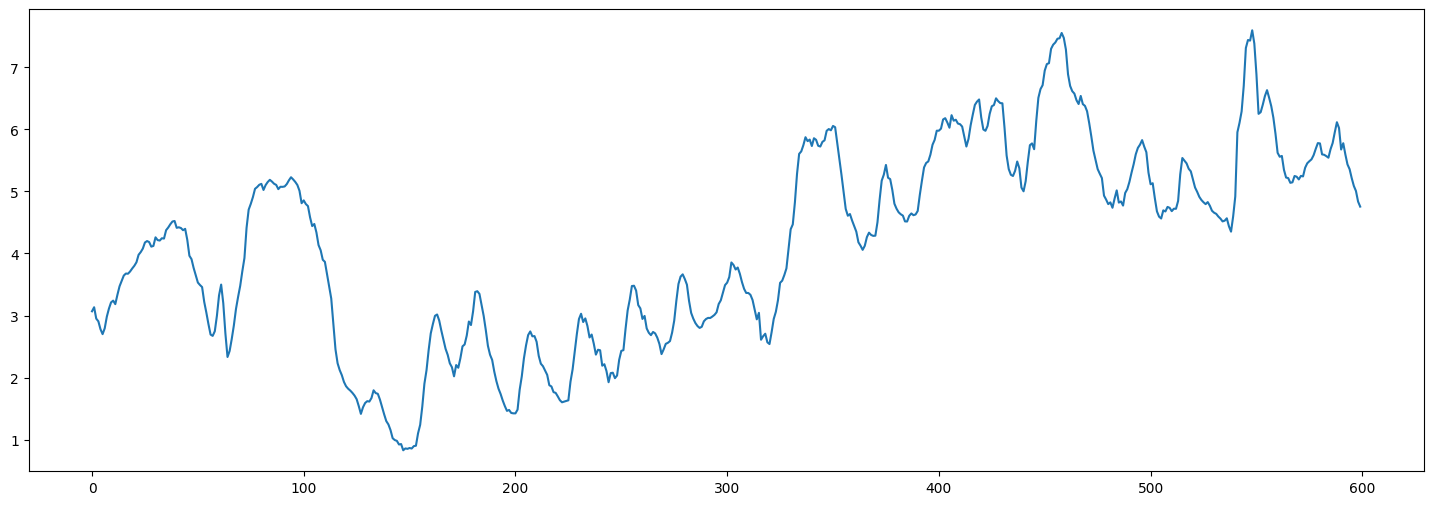

In [10]:
plt.figure(figsize=(18, 6))
plt.plot(df['H2OC (mmol/mol)'])

In [11]:
df.shape, df.dtypes

((600, 15),
 Date Time          datetime64[ns]
 p (mbar)                  float64
 T (degC)                  float64
 Tpot (K)                  float64
 Tdew (degC)               float64
 rh (%)                    float64
 VPmax (mbar)              float64
 VPact (mbar)              float64
 VPdef (mbar)              float64
 sh (g/kg)                 float64
 H2OC (mmol/mol)           float64
 rho (g/m**3)              float64
 wv (m/s)                  float64
 max. wv (m/s)             float64
 wd (deg)                  float64
 dtype: object)

### Smoothing using rolling mean

In [12]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()
df.head(5)

/tmp/ipykernel_111635/2014813997.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.526500,-8.184500,265.239833,-8.990833,93.856667,3.291667,3.089833,0.201833,1.930833,3.100667,1308.588833,0.418333,0.856833,173.438333
2,2009-01-01 02:00:00,996.599333,-8.377444,265.041556,-9.197222,93.748889,3.242778,3.039889,0.201778,1.899444,3.050444,1309.664778,0.361667,0.773444,181.231111
3,2009-01-01 03:00:00,996.696167,-8.507250,264.904083,-9.344583,93.611667,3.210000,3.004500,0.203833,1.877500,3.014500,1310.451917,0.315417,0.731750,175.194167
4,2009-01-01 04:00:00,996.788600,-8.675467,264.728600,-9.544667,93.366000,3.168333,2.958600,0.209400,1.848667,2.967600,1311.432533,0.310333,0.719400,170.174000


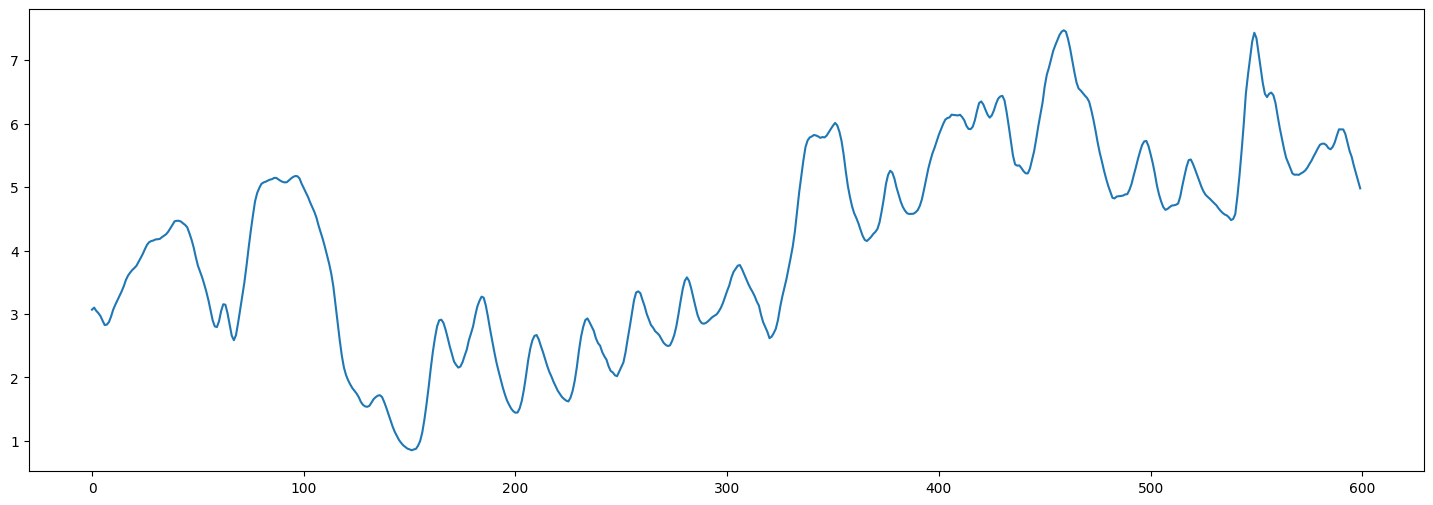

In [13]:
plt.figure(figsize=(18, 6))
plt.plot(df['H2OC (mmol/mol)'])

In [14]:
TOTAL_POINTS = len(df)
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = TOTAL_POINTS // PERIOD
FEATURES = 14
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 24 x 14


In [15]:
data = df[numeric_cols][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 14)

In [16]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 14)
Test tensor shape: (5, 24, 14)


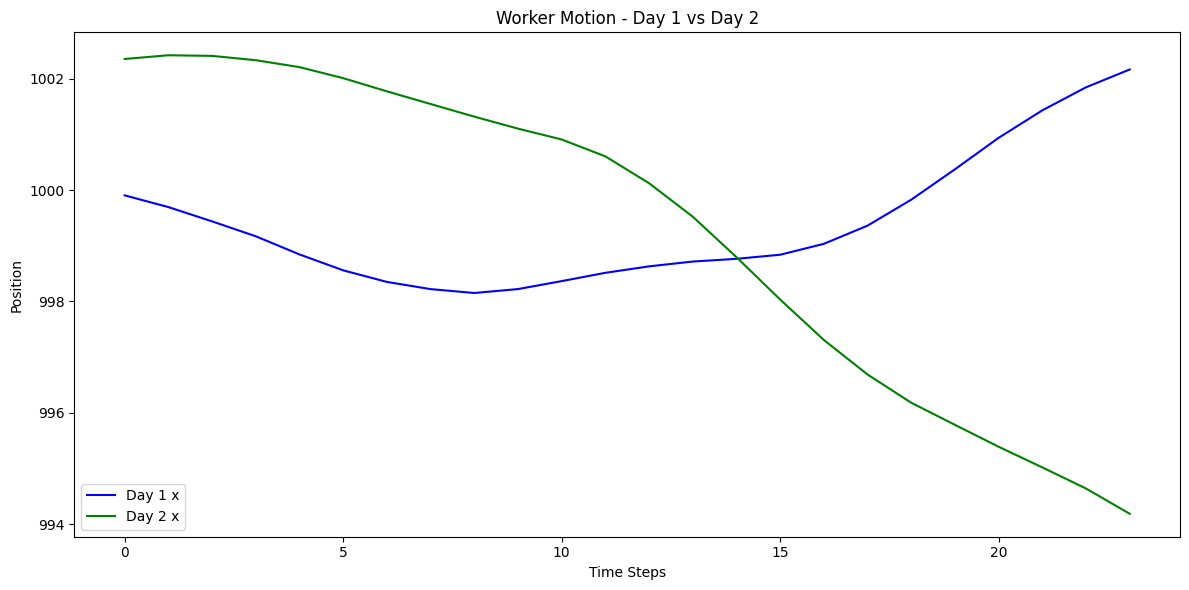

In [21]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [22]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (14, 2)


In [27]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 14)
Reconstructed tensor shape: (20, 24, 14)


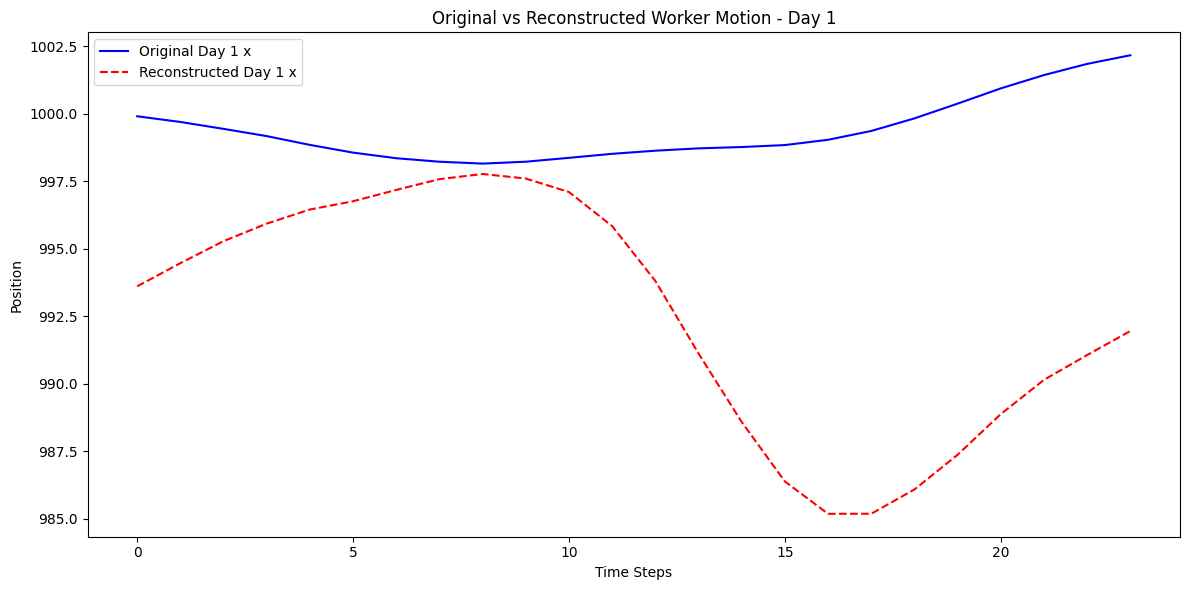

In [28]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [29]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

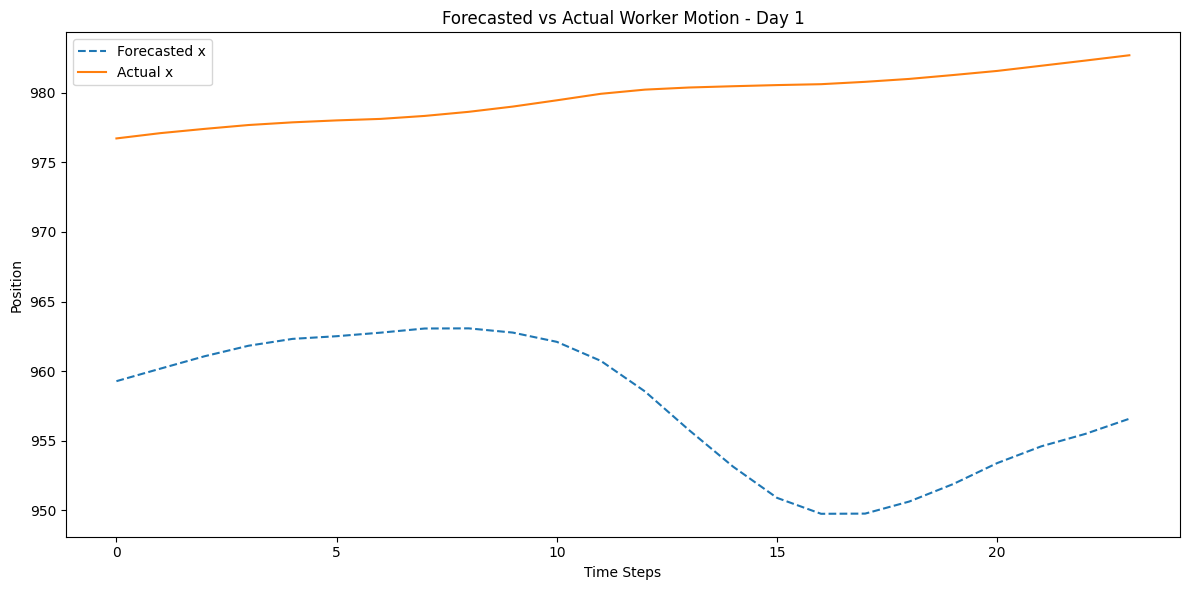

In [30]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

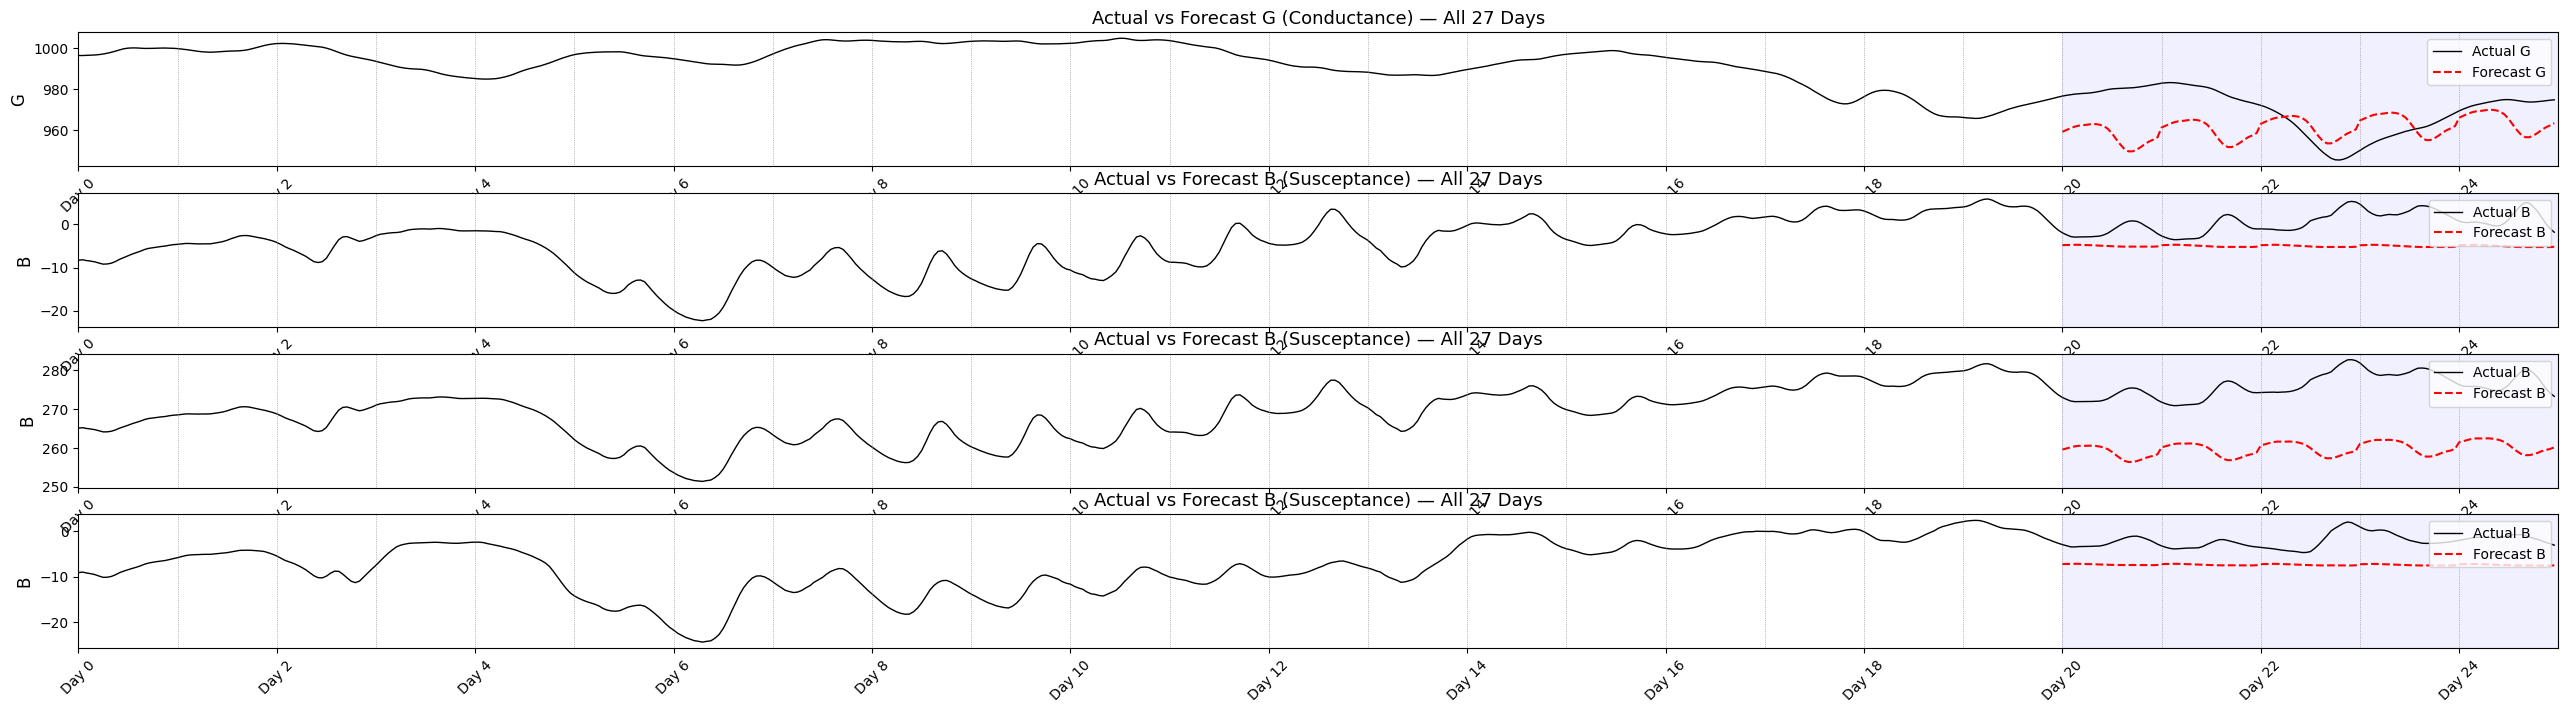

In [31]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(32, 8))

plt.subplot(4, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

Test series shape: (120, 14)
Forecast series shape: (120, 14)
x shape: (120,)


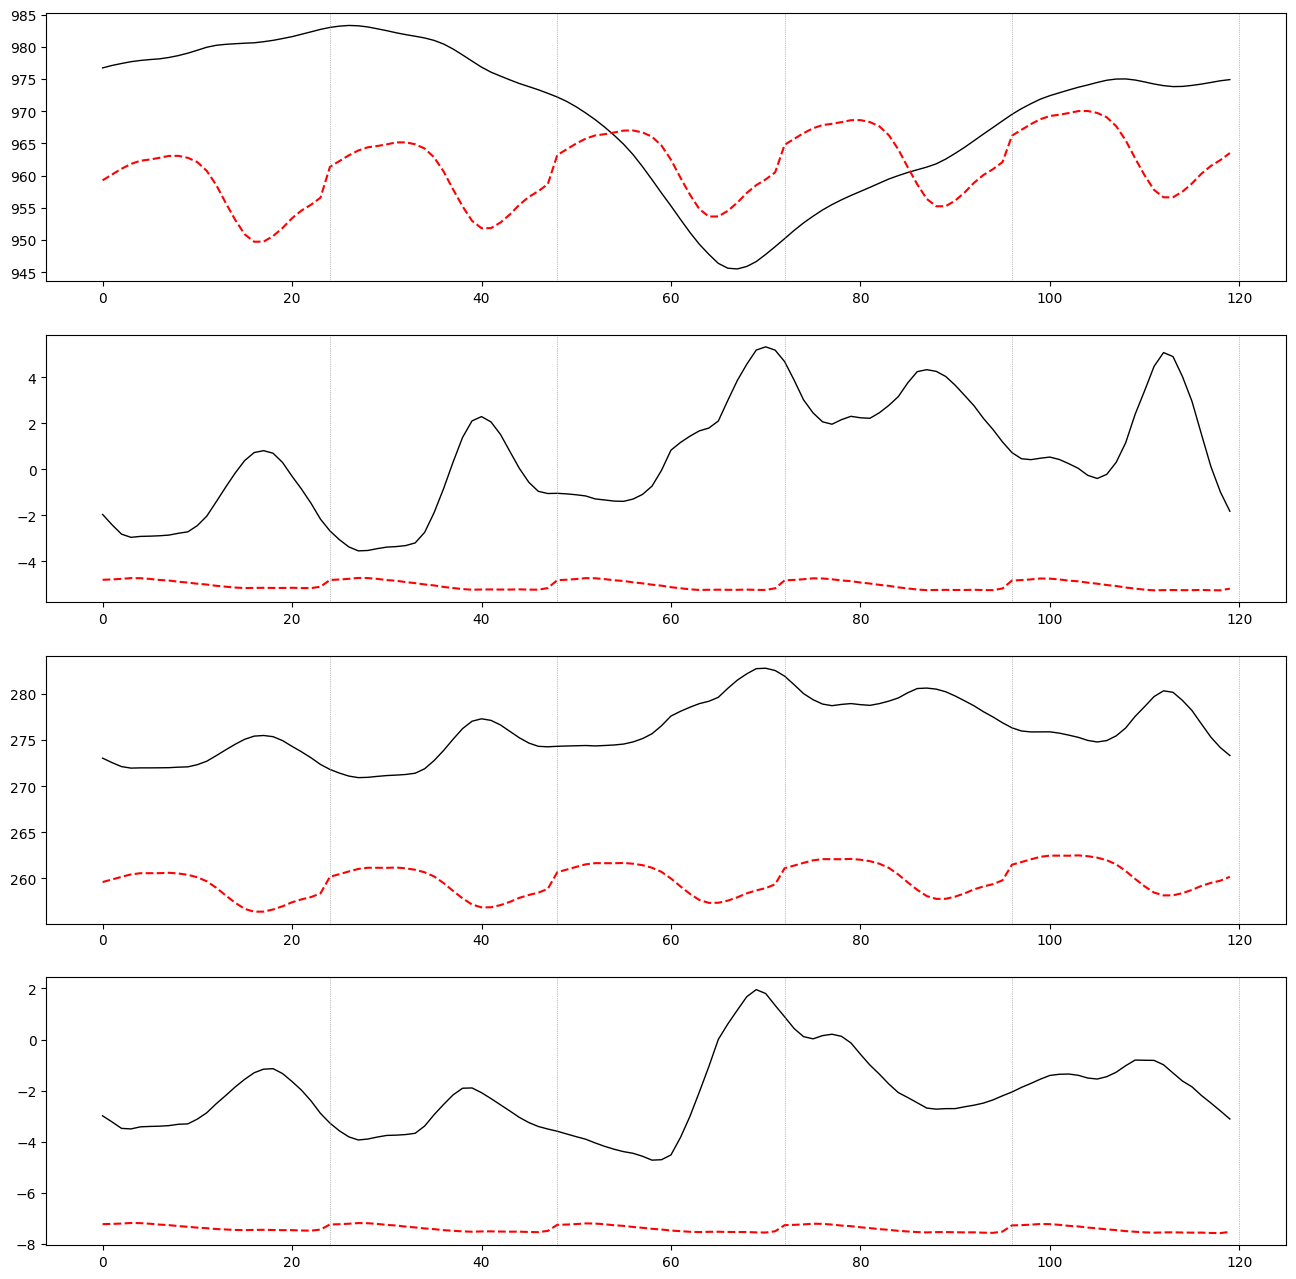

In [32]:
# Flatten full tensor and forecast tensor into time series
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)
plt.figure(figsize=(16, 16))

print(f"Test series shape: {test_series.shape}")
print(f"Forecast series shape: {forecast_series.shape}")
print(f"x shape: {x.shape}")

plt.subplot(4, 1, 1)
plt.plot(test_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 2)
plt.plot(test_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 3)
plt.plot(test_series[:, 2], 'k-', lw=1, label='Actual C')
plt.plot(forecast_series[:, 2], 'r--', lw=1.5, label='Forecast C')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 4)
plt.plot(test_series[:, 3], 'k-', lw=1, label='Actual D')
plt.plot(forecast_series[:, 3], 'r--', lw=1.5, label='Forecast D')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)


In [33]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 14), (120, 14))

In [34]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

r2_a = r2_score(test_series[:, 0], forecast_series[:, 0])
r2_b = r2_score(test_series[:, 1], forecast_series[:, 1])
r2_c = r2_score(test_series[:, 2], forecast_series[:, 2])
r2_d = r2_score(test_series[:, 3], forecast_series[:, 3])
# r2_e = r2_score(test_series[:, 4], forecast_series[:, 4])
# r2_f = r2_score(test_series[:, 5], forecast_series[:, 5])
# r2_g = r2_score(test_series[:, 6], forecast_series[:, 6])

r2_scores = {
    'Col 1': r2_a,
    'Col 2': r2_b,
    'Col 3': r2_c,
    'Col 4': r2_d,
    # 'Col 5': r2_e,
    # 'Col 6': r2_f,
    # 'Col 7': r2_g
}

r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Column', 'R² Score'])
print(r2_scores_df)

  Column   R² Score
0  Col 1  -0.967880
1  Col 2  -5.149856
2  Col 3 -27.392514
3  Col 4 -12.253591
